In [1]:
# important: run these two notebooks first!
%run MultilineQueuesTypeC.ipynb
%run Crystals.ipynb

# Multiline Queues in Type C

This file contains several examples of the use of the Crystals.ipynb and MultilineQueuesTypeC.ipynb methods

## Object construction

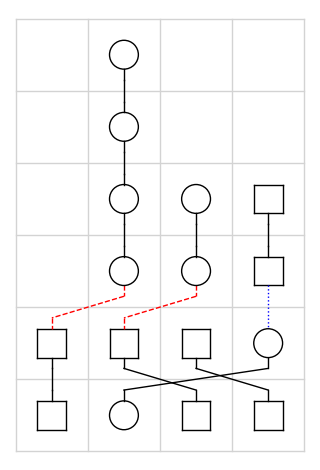

Projection: [-3, 2, -2, -1]
Left bouncing: True


In [2]:
balls = [[-1,1,-1,-1], [-1, -1, -1,1], [0,1,1,-1],[0,1,1,-1], [0, 1, 0, 0], [0, 1, 0, 0]]

M = MultilineQueueC(balls)
M.pair(0)
r = 0.2
M.draw(r)
print(f"Projection: {M.projection()}")
print(f"Left bouncing: {M.is_left_bouncing()}")

In [341]:
M.maj()

3

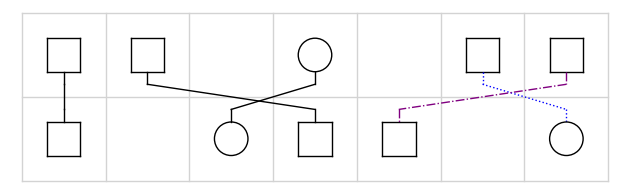

True

In [3]:
balls = [[-1,0,1,-1,-1,0,1], [-1,-1,0,1,0,-1,-1]]

M = MultilineQueueC(balls)
M.pair(0)

r = 0.2
M.draw(r)
M.is_left_bouncing()

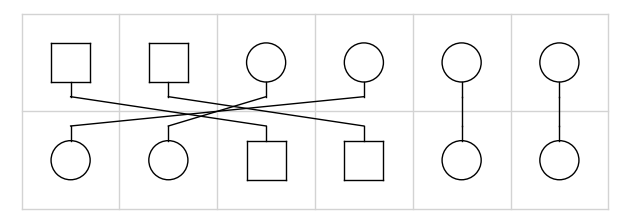

False

In [66]:
%run MultilineQueuesTypeC.ipynb
n=6
Q1 = [3,-3,4,-4,5,6]
balls = to_number_matrix_arrays(n,[Q1])

M = MultilineQueueC(balls)
M.pair(0)
r = 0.2
M.draw(r)
M.is_left_bouncing()

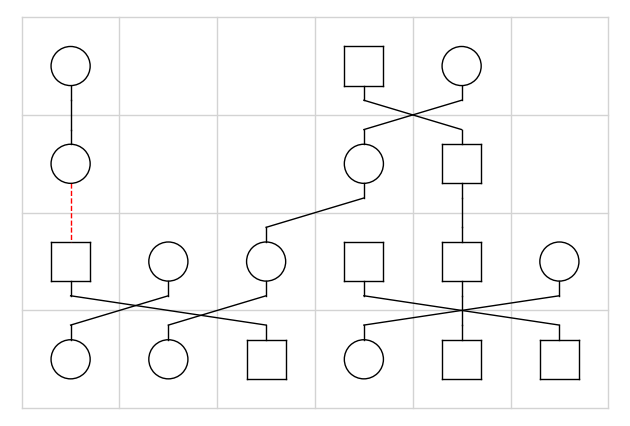

In [7]:
n = 6
Q2 = [1,5,-5]
Q1 = [2,3,6,-6,-5,-3]
balls = to_number_matrix_arrays(n,[Q1]) + to_number_matrix_arrays(n,[Q2])

M = MultilineQueueC(balls)
M.pair(0)
r = 0.2
M.draw(r)

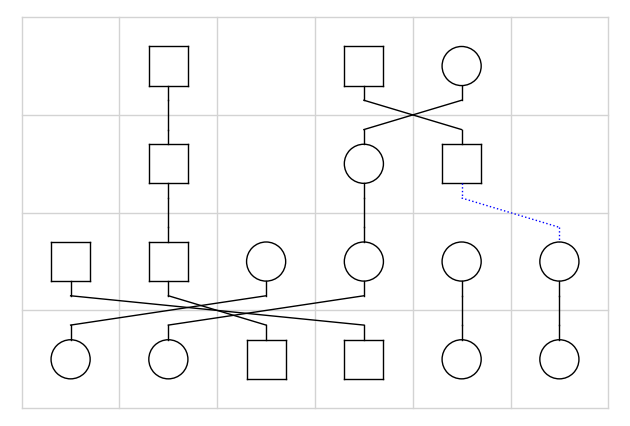

In [23]:
n = 6
Q2 = [-2,5,-5]
Q1 = [3,-3,4,-4,5,6]
balls = to_number_matrix_arrays(n,[Q1]) + to_number_matrix_arrays(n,[Q2])

M = MultilineQueueC(balls)
M.pair(0)
r = 0.2
M.draw(r)

## Projection to open-TASEP states

In [6]:
# Produces the projections of all the elements of the tensor product

n = 3
lam = [3,1]

list_crystals = []

for i in range(len(lam)):
    list_crystals.append(crystals.KirillovReshetikhin(['C',n,1],lam[i],1))

prod = crystals.TensorProduct(*list_crystals)

states = []

print(f"There are {(len(prod))} MLQs of shape {lam}: ")
cant = 0
for p in prod:
    r = 0.2
    balls = to_number_matrix(n,p)
    M = MultilineQueueC(balls)
    M.pair(0)
    # print(p)
    # print(balls)
    # print("Queues")
    # for q in M.queues:
    #     print(q)
    # print("\n")
    # M.draw(r)
    # states.append(M.projection())

    fState = [1,2,-1]
    if M.projection() == fState:
        # print(p)
        # print(balls)
        # print("Queues")
        # for q in M.queues:
        #     print(q)
        # print("\n")
        # M.draw(r)
        cant += 1

print(f"There are {cant} MLQs which project to {fState}")
    

There are 84 MLQs of shape [3, 1]: 
There are 8 MLQs which project to [1, 2, -1]


## Crystal Markov Chain in type C

### Verification of balancing condition

In [9]:
# finds the ball arrangement that can be reached from "balls" by one transition in the Crystal Markov Chain
def going_out_from(balls,show):
    n = len(balls[0])
    M = MultilineQueueC(balls)
    M.pair(0)
    proj1 = M.projection()
    rw0 = M.rw()
    
    going_out = []

    if show:
        print("Going out:")
    
    for i in range(0,n+1):
        phi_i = M.phi(i)
        for j in range(1,phi_i+1):
            w = M.ring(i,j)
            fixed_w = fix_pieces(w,M.shape)
            if w != rw0 and fixed_w not in going_out and w != []:
                going_out.append(fixed_w)                    
    
    if show:
        print(going_out)

    return(going_out)
    

# finds the ball arrangement that go into "balls" by one transition in the Crystal Markov Chain
def going_in_to(balls,show):
    n = len(balls[0])
    M = MultilineQueueC(balls)
    M.pair(0)
    rw0 = M.rw()
    proj1 = M.projection()
    mlq_shape = M.shape
    n = M.size[0]
    
    view = False
    
    list_word_sets = []
    
    for i in (range(len(mlq_shape))):
        list_word_sets.append([x for x in generate_lists(n,mlq_shape[i]) if is_type_C_valid_word(x,n)])
    
    prod = itertools.product(*list_word_sets)
    
    all_words = [list_flatten(x) for x in prod]
    
    # print("Number of MLQs: "+str(len(prod)))

    going_in = []

    if show:
        print("Going in")
    
    all_good = True
    for w in all_words:
        r = 0.2
        bs = ball_arrangement_from_word(w,mlq_shape,n)
        M2 = MultilineQueueC(bs)
        M2.pair(0)
        rw2 = M2.rw()
        for i in range(0,n+1):
            phi_i = M2.phi(i)
            for j in range(1,phi_i+1):
                wr = M2.ring(i,j)
                balls_r = ball_arrangement_from_word(wr,M.shape,n)
                Mr = MultilineQueueC(balls_r)
                w = Mr.rw()
                if w == rw0 and balls != bs and rw2 not in going_in:
                    going_in.append( rw2 )

    if show:
        print(going_in)
    
    return(going_in)


# returns lists of "k" numbers in "n" elements with possible signs
def generate_lists(n, k):
    result = []
    numbers = list(range(1, n + 1))

    # p = number of positive elements
    for p in range(k + 1):
        q = k - p  # number of negative elements

        # choose p distinct numbers for positives
        for pos in combinations(numbers, p):
            # choose q distinct numbers for negatives
            for neg in combinations(numbers, q):
                
                # positives strictly increasing
                pos_part = sorted(pos)
                
                # negatives strictly increasing
                neg_part = sorted(-x for x in neg)
                
                result.append(pos_part + neg_part)

    return result
    

# returns a flattened version of "lst"
def list_flatten(lst):
    result = []
    for item in lst:
        if isinstance(item, list):
            result.extend(flatten(item))
        else:
            result.append(item)
    return result


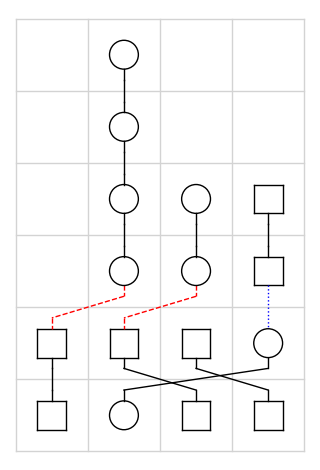

[2, 2, 3, -4, 4, -4, -3, -1]
4
4


Going out: 4


In [14]:
balls = ball_arrangement_from_word([-2, 1, -2],[1,2],2)
balls = [[-1,1,-1,-1], [-1, -1, -1,1], [0,1,1,-1],[0,1,1,-1], [0, 1, 0, 0], [0, 1, 0, 0]]

# balls = [[-1, -1, 1], [-1, -1, 1], [0, 1, -1], [0, -1, 1]]

r = 0.2

M = MultilineQueueC(balls)
M.pair(0)
M.draw(r)
print(M.rw())

print(sum([M.epsilon(i) for i in range(0,M.size[0]+1)]))
print(sum([M.phi(i) for i in range(0,M.size[0]+1)]))

print("\n")


show = False

print(f"Going out: {len(going_out_from(balls,show))}")
# print(f"Going in: {len(going_in_to(balls,show))}")

In [7]:
# Checks the epsilon-phi condition for Type C

%run MultilineQueuesTypeC.ipynb

lam = Partition([3,1])
n = 5

mlq_shape = list(lam.conjugate())

view = False

list_word_sets = []

for i in (range(len(mlq_shape))):
    list_word_sets.append([x for x in generate_lists(n,mlq_shape[i]) if is_type_C_valid_word(x,n)])

prod = itertools.product(*list_word_sets)

all_words = [list_flatten(x) for x in prod]

# print("Number of MLQs: "+str(len(prod)))

all_good = True
for w in all_words:
    r = 0.2
    balls = ball_arrangement_from_word(w,mlq_shape,n)
    M = MultilineQueueC(balls)
    boo = sum( [M.epsilon(i) for i in range(n+1)] ) == sum( [M.phi(i) for i in range(n+1)] )

    if not boo:
        all_good = True
        print("Mistake in epsilon-phi")
        M.draw(r)
        print(sum( [M.epsilon(i) for i in range(n+1)] ) , sum( [M.phi(i) for i in range(n+1)] ))

if all_good:
    print("No mistakes!")
    

No mistakes!


In [107]:
# Checking balance of the incoming and outgoing transitions (directly = SLOW!!!!)

%run MultilineQueuesTypeC.ipynb

lam = Partition([2,1])
n = 2

mlq_shape = list(lam.conjugate())[::-1]

view = False

list_word_sets = []

for i in (range(len(mlq_shape))):
    list_word_sets.append([x for x in generate_lists(n,mlq_shape[i]) if is_type_C_valid_word(x,n)])

prod = itertools.product(*list_word_sets)

all_words = [list_flatten(x) for x in prod]

# print("Number of MLQs: "+str(len(prod)))

all_good = True

for w in all_words:
    r = 0.2
    balls = ball_arrangement_from_word(w,mlq_shape,n)
    M = MultilineQueueC(balls)
    M.pair(0)
    if view:
        M.draw(r)

    if (len(going_out_from(balls,False)) != len(going_in_to(balls,False))):
        all_good = False
        print(balls)
        print(going_out_from(balls,show))
        print(going_in_to(balls,show))
        print("\n")

if all_good:
    print("\n")
    print("ALL GOOD!")
    print("\n")

    



ALL GOOD!




In [4]:
# Checking balance of the incoming and outgoing transitions (with digraph = NICE!)

%run MultilineQueuesTypeC.ipynb

lam = Partition([2,2])
n = 2

mlq_shape = list(lam.conjugate())[::-1]

view = False

list_word_sets = []

for i in (range(len(mlq_shape))):
    list_word_sets.append([x for x in generate_lists(n,mlq_shape[i]) if is_type_C_valid_word(x,n)])

prod = itertools.product(*list_word_sets)

all_words = [list_flatten(x) for x in prod]

# print("Number of MLQs: "+str(len(prod)))

all_good = True

adj_dict = {}

for word in all_words:
    adj_dict[str(word)] = []

keys = list(adj_dict.keys())

for I in range(len(all_words)):
    w = all_words[I]
    r = 0.2
    balls = ball_arrangement_from_word(w,mlq_shape,n)
    M = MultilineQueueC(balls)
    M.pair(0)
    going_out = going_out_from(balls,False)
    for x in going_out:
        adj_dict[keys[I]].append(str(x))

G = DiGraph(adj_dict)

all_good = True
for v in G.vertices():

    if not G.in_degree(v) == G.out_degree(v):
        print("Mistake!")
        print(v)
        print(G.in_degree(v) , G.out_degree(v))
        print(adj_dict[str(v)])
    
    if not len(G.neighbors_in(v)) == len(G.neighbors_out(v)):
        print("Mistake!!")
        print(v)
        print(G.neighbors_in(v))
        print(G.neighbors_out(v))
        all_good = False

if all_good:
    print("\n")
    print("ALL GOOD!")
    print("\n")




ALL GOOD!




### Lumping

In [27]:
# Checking the lumping conditions

# Checking balance of the incoming and outgoing transitions (with digraph = NICE!)

%run MultilineQueuesTypeC.ipynb

lam = Partition([4,2,1])
n = 4

mlq_shape = list(lam.conjugate())[::-1]

view = False

list_word_sets = []

for i in (range(len(mlq_shape))):
    list_word_sets.append([x for x in generate_lists(n,mlq_shape[i]) if is_type_C_valid_word(x,n)])

prod = itertools.product(*list_word_sets)

all_words = [list_flatten(x) for x in prod]

# print("Number of MLQs: "+str(len(prod)))

all_good = True

adj_dict = {}

for word in all_words:
    adj_dict[str(word)] = []

keys = list(adj_dict.keys())

for I in range(len(all_words)):
    w = all_words[I]
    r = 0.2
    balls = ball_arrangement_from_word(w,mlq_shape,n)
    M = MultilineQueueC(balls)
    M.pair(0)
    going_out = going_out_from(balls,False)
    for x in going_out:
        adj_dict[keys[I]].append(str(x))

G = DiGraph(adj_dict)

all_good = True
import ast

for v in G.vertices():
    lst_v = ast.literal_eval(v)

    balls1 = ball_arrangement_from_word(lst_v,mlq_shape,n)
    M = MultilineQueueC(balls1)
    M.pair(0)
    proj1 = M.projection()

    # 1. If a_i > a_{i+1} then phi_i(M) > 0 and transition only happens for j = phi_i(M).

    for i in range(0,len(proj1)+1):
        if i < n and i > 0:

            if proj1[i-1] > proj1[i]:
                phii = M.phi(i)
                if not phii > 0:
                    print("Mistake 1.1")
                    all_good = False
                else:
                    for j in range(1,phii+1):
                        w = M.ring(i,j)
                        b2 = ball_arrangement_from_word(w,M.shape,M.size[0])
                        M2 = MultilineQueueC(b2)
                        M2.pair(0)
                        proj2 = M2.projection()
                        
                        if j != phii and proj1 != proj2:
                            print("Mistake 1.2")
                            all_good = False
                        elif j== phii and proj1 == proj2:
                            print("Mistake 1.3")
                            all_good = False

        if i == 0:
            if proj1[0] < 0:
                phii = M.phi(i)
                if not phii > 0:
                    print("Mistake 2.1")
                    all_good = False
                else:
                    for j in range(1,phii+1):
                        w = M.ring(i,j)
                        b2 = ball_arrangement_from_word(w,M.shape,M.size[0])
                        M2 = MultilineQueueC(b2)
                        M2.pair(0)
                        proj2 = M2.projection()
                        
                        if j != phii and proj1 != proj2:
                            print("Mistake 2.2")
                            all_good = False
                        elif j== phii and proj1 == proj2:
                            print("Mistake 2.3")
                            all_good = False

        if i == n:
            if proj1[n-1] > 0:
                phii = M.phi(i)
                if not phii > 0:
                    print("Mistake 3.1")
                    all_good = False
                else:
                    for j in range(1,phii+1):
                        w = M.ring(i,j)
                        b2 = ball_arrangement_from_word(w,M.shape,M.size[0])
                        M2 = MultilineQueueC(b2)
                        M2.pair(0)
                        proj2 = M2.projection()
                        
                        if j != phii and proj1 != proj2:
                            print("Mistake 3.2")
                            print(balls1)
                            all_good = False
                        elif j== phii and proj1 == proj2:
                            print("Mistake 3.3")
                            all_good = False


    #2 If phi_k(M) > 0 and transition only happens for j = phi_k(M) then a_k > a_{k+1}

    for k in range(1,n+1):
        phik = M.phi(k)
        if phik > 0:
            only_max = True
            for j in range(1,phik+1):
                w = M.ring(k,j)
                b2 = ball_arrangement_from_word(w,M.shape,M.size[0])
                M2 = MultilineQueueC(b2)
                M2.pair(0)
                proj2 = M2.projection()
                if j < phik and proj1 != proj2:
                    only_max = False
                    print("Mistake 4.")
                    all_good = False
                    break

                if j == phik and proj1 == proj2:
                    only_max = False
                    if k < n and k > 0:
                        if proj1[k-1] > proj1[k]:
                            print("Mistake 5.")
                            all_good = False
                    elif k==n:
                        if proj1[n-1] > 0:
                            print("Mistake 5.")
                            all_good = False
                    elif k==1:
                        if proj1[0] < 0:
                            print("Mistake 5.")
                            all_good = False

            if only_max:
                if k < n and k > 0:
                    if proj1[k-1] < proj1[k]:
                        print("Mistake 6.")
                        all_good = False
                elif k==n:
                    if proj1[n-1] < 0:
                        print("Mistake 6.")
                        all_good = False
                elif k==1:
                    if proj1[0] > 0:
                        print("Mistake 6.")
                        all_good = False
    
    

if all_good:
    print("\n")
    print("ALL GOOD!")
    print("\n")




ALL GOOD!




In [20]:
import ast

for v in G.vertices():
    lst_v = ast.literal_eval(v)

    balls1 = ball_arrangement_from_word(lst_v,mlq_shape,n)
    M1 = MultilineQueueC(balls1)
    M1.pair(0)
    proj1 = M1.projection()
    
    out_neigh = G.neighbors_out(v)
    for x in out_neigh:
        lst_x = ast.literal_eval(x)
        balls2 = ball_arrangement_from_word(lst_x,mlq_shape,n)
        M2 = MultilineQueueC(balls2)
        M2.pair(0)
        proj2 = M2.projection()

        
        
    

[-1, -1, -1, 3, -3]


### State diagram

In [157]:
lam = Partition([1,1])
n = 4

mlq_shape = list(lam.conjugate())[::-1]

view = False

list_word_sets = []

for i in (range(len(mlq_shape))):
    list_word_sets.append([x for x in generate_lists(n,mlq_shape[i]) if is_type_C_valid_word(x,n)])

prod = itertools.product(*list_word_sets)

all_words = [list_flatten(x) for x in prod]

# print("Number of MLQs: "+str(len(prod)))

all_good = True

adj_dict = {}

for word in all_words:
    adj_dict[str(word)] = []

keys = list(adj_dict.keys())

for I in range(len(all_words)):
    w = all_words[I]
    r = 0.2
    balls = ball_arrangement_from_word(w,mlq_shape,n)
    M = MultilineQueueC(balls)
    M.pair(0)
    going_out = going_out_from(balls,False)
    for x in going_out:
        adj_dict[keys[I]].append(str(x))

G = DiGraph(adj_dict)

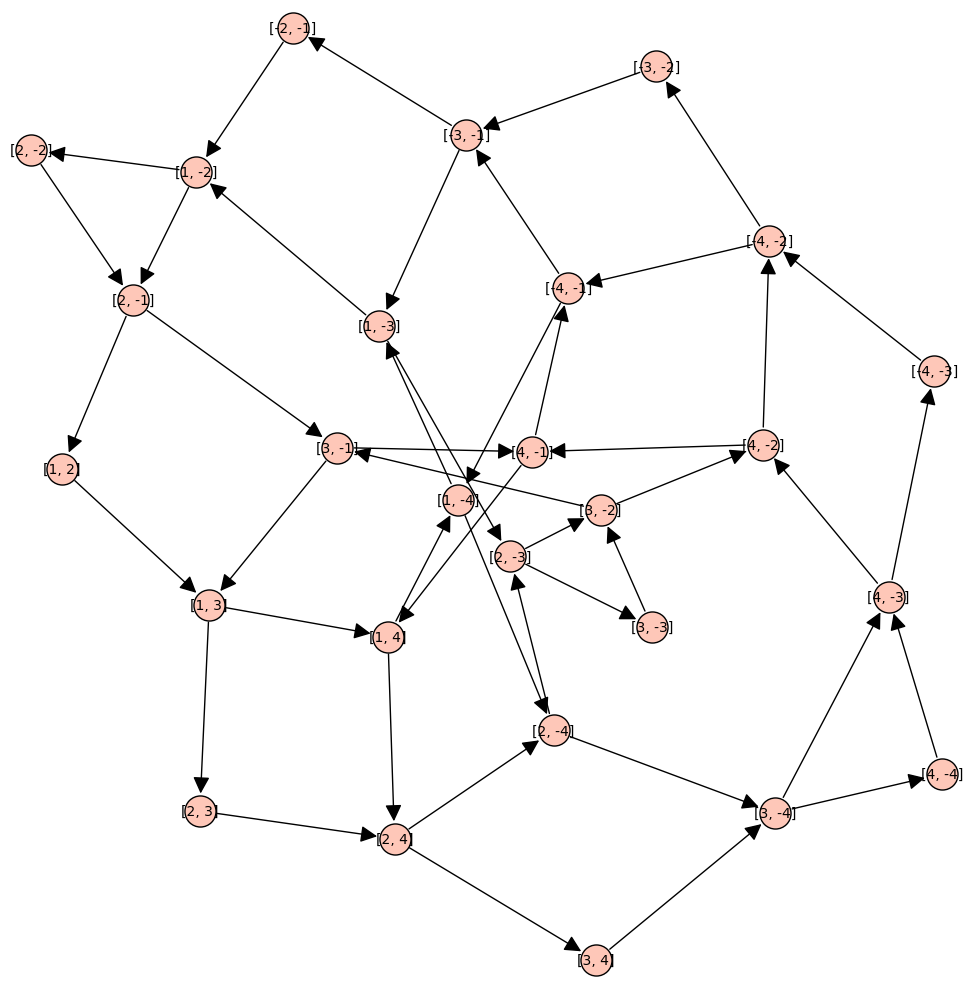

In [161]:
size = 10
Gplt = G.graphplot(vertex_size=500,figsize = [size,size])

Gplt.plot()

### Some other ideas

In [154]:
# Methods to compute the number of walks in a given digraph G using adjacency matrices

def number_walks_k_steps_from_v(v,k,G):
    A = G.adjacency_matrix()
    vs = G.vertices()
    N = len(vs)

    i = vs.index(v)
    
    Mat = A^k
    return(sum([Mat[i][j] for j in range(N)]))

def number_walks_k_steps_to_v(v,k,G):
    A = G.adjacency_matrix()
    vs = G.vertices()
    N = len(vs)

    i = vs.index(v)
    
    Mat = A^k
    return(sum([Mat[j][i] for j in range(N)]))

# Proportion of walks coming in and coming out of a given vertex

k = 10

lst_walks_from = []
lst_walks_to = []

for v in G.vertices():
    lst_walks_from.append(number_walks_k_steps_from_v(v,k,G))
    lst_walks_to.append(number_walks_k_steps_to_v(v,k,G))
    # print(v , number_walks_k_steps_from_v(v,k,G) , number_walks_k_steps_to_v(v,k,G))

In [155]:
print(len(set(lst_walks_from)),set(lst_walks_from))

24 {6272, 3458, 7435, 5264, 3475, 4760, 3489, 4777, 6571, 2860, 3502, 1459, 1462, 3382, 3388, 4161, 1474, 6724, 4550, 3409, 4439, 1518, 4724, 7669}


In [156]:
print(len(set(lst_walks_to)),set(lst_walks_to))

24 {6272, 3458, 7435, 5264, 3475, 4760, 3489, 4777, 6571, 2860, 3502, 1459, 3382, 1462, 3388, 4161, 1474, 6724, 4550, 3409, 4439, 1518, 4724, 7669}


In [149]:
sorted(lst_walks_from) == sorted(lst_walks_to)

True

## Collapsing in Type C

In [223]:
%run MultilineQueuesTypeC.ipynb

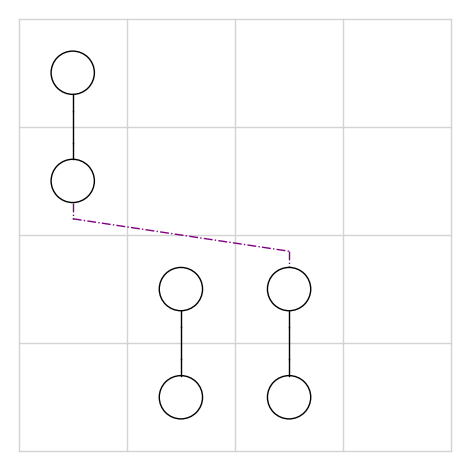

In [135]:
B = [0,1,1,0]
T = [1,0,0,0]

# Y = [[0, 0, -1, -1], [0, 0, -1, -1]]
# X = [[0, -1, 0, 1], [0, -1, 0, 1]]

Y = [T,T]
X = [B,B]

balls = X + Y

M = MultilineQueueC(balls)
M.pair(0)
M.draw(0.2)

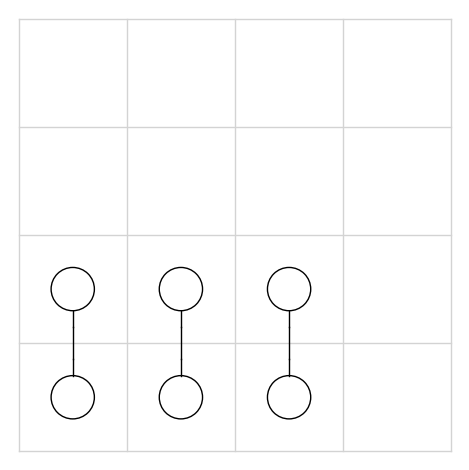

In [136]:
balls2 = row_operator(X,Y)

M2 = MultilineQueueC(balls2[0]+balls2[1])
M2.pair(0)
M2.draw(0.2)

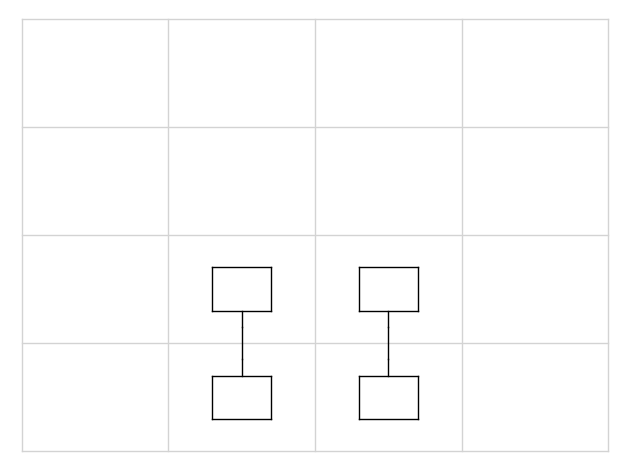

In [21]:
X2 = balls2[0]
Y2 = balls2[1]

balls3 = row_operator(X2,Y2)

M3 = MultilineQueueC(balls3[0]+balls3[1])
M3.pair(0)
M3.draw(0.2)

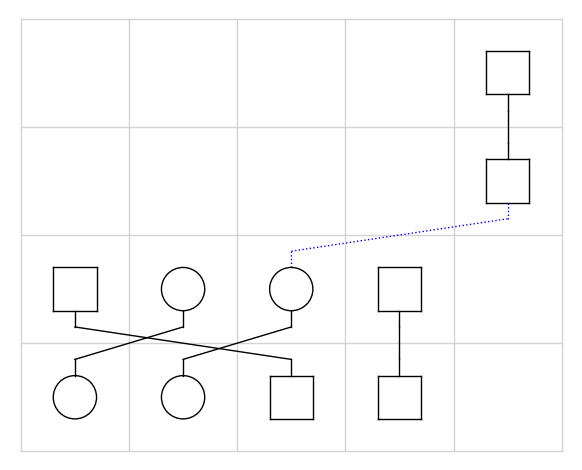

In [185]:
balls2 = row_operator_star(X,Y)

M2 = MultilineQueueC(balls2[0]+balls2[1])
M2.pair(0)
M2.draw(0.2)

In [342]:
%run MultilineQueuesTypeC.ipynb

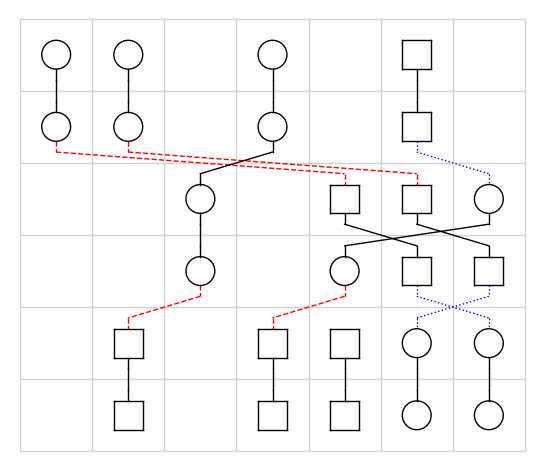

[3, 3, 3, 3, 1]

In [343]:
# Z = [[1,1,0,-1,0],[1,1,0,-1,0]]
# Y = [[0,1,-1,1,-1],[0,-1,1,1,-1]]
# X = [[1,0,1,-1,-1],[1,0,-1,-1,1]]

# Z = [[1,0,0,1,0],[1,0,0,1,0]]
# Y = [[0,1,1,1,-1],[0,1,1,1,-1]]
# X = [[1,0,1,-1,-1],[1,0,-1,-1,1]]

Z = [[1,1,0,1,0,-1,0],[1,1,0,1,0,-1,0]]
Y = [[0,0,1,0,1,-1,-1],[0,0,1,0,-1,-1,1]]
X = [[0,-1,0,-1,-1,1,1],[0,-1,0,-1,-1,1,1]]

balls = X + Y + Z

M = MultilineQueueC(balls)
M.pair(0)
M.draw(0.2)
M.partition()

In [344]:
M.maj()

6

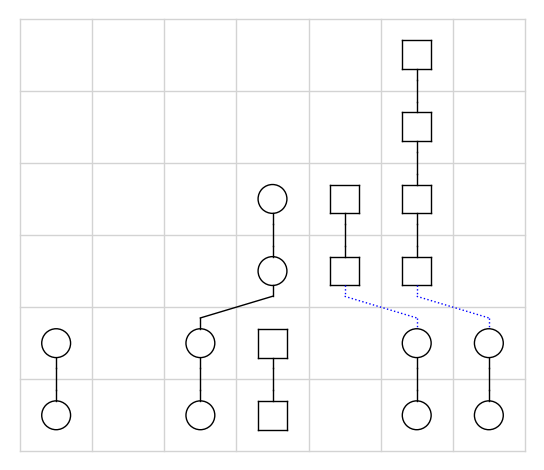

[[1, 1, 1, 1, 1, 2, 2], [2, 2, 3, -3, -3], [3]]

In [345]:
balls2 = M.collapse_and_record()

M2 = MultilineQueueC(balls2)
M2.pair(0)
M2.draw(0.2)

M.QM

In [346]:
M2.maj()

0

[[1, 0, 1, -1, -1], [1, 0, -1, -1, 1]] [[0, 1, 1, 1, -1], [0, 1, 1, 1, -1]]


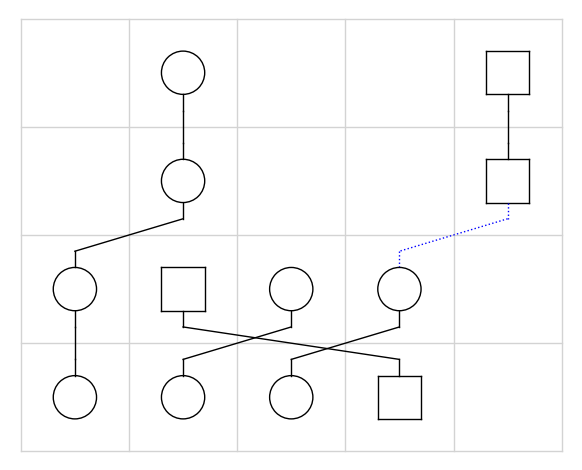

In [123]:
print(X,Y)

balls2 = row_operator_star(X,Y)

M2 = MultilineQueueC(balls2[0]+balls2[1])
M2.pair(0)
M2.draw(0.2)

## Comparing sizes of wrapping and non-left-bouncing type C MLQs (unfinished)

In [196]:
def number_TypeC_MLQs(n,row_cont):
    ans = 1

    for i in range(len(row_cont)):
        ans *= len(list(crystals.KirillovReshetikhin(['C',n,1],row_cont[i],1)))
        
    return(ans)

def number_NonLeftBouncing_TypeC_MLQs(n,row_cont):
    ans = 0
    
    list_crystals = []
    for i in range(len(row_cont)):
        list_crystals.append(crystals.KirillovReshetikhin(['C',n,1],row_cont[i],1))
    prod = crystals.TensorProduct(*list_crystals)

    for p in prod:
        balls = to_number_matrix(n,p)
        M = MultilineQueueC(balls)
        M.pair(0)
        if not M.is_left_bouncing():
            ans += 1

    return(ans)

In [201]:
lam = Partition([3,2,1])
row_cont = lam.conjugate()

print(row_cont)
n = 5

number_TypeC_MLQs(n,row_cont)

[3, 2, 1]


48400

In [202]:
number_NonLeftBouncing_TypeC_MLQs(n,row_cont)

17920

## Recording object characterization

### Preliminaries

In [37]:
# Need these methods for this section

## Methods for understanding the recording objects

def remove_trailing_zeros(arr):
    # Find the index of the last non-zero element from the right
    i = len(arr) - 1
    while i >= 0 and arr[i] == 0:
        i -= 1
    return arr[: i + 1]

def shape(Q):
    sh = []
    for i in range(len(Q)):
        sh.append(len(Q[i]))
    return(remove_trailing_zeros(sh))

def core_shape(Q):
    sh = shape(Q)
    ans = []
    for i in range(len(sh)-1):
        num_negs_curr = len([x for x in Q[i] if x<0])
        num_negs_next = len([x for x in Q[i+1] if x<0])
        ans.append(sh[i]-num_negs_curr-num_negs_next)
    ans.append(sh[len(sh)-1]-len([x for x in Q[len(sh)-1] if x<0]))
    return(remove_trailing_zeros(ans))


# Generating all tableaux (thanks Gemini)

from sage.combinat.tableau import Tableau

def generate_king_tableaux(n, lam, mu):
    """
    Generates all King (symplectic) tableaux of shape `lam` with absolute content `mu`.
    
    Parameters:
    - n (int): Maximum value bound for alphabet {1, -1, ..., n, -n}
    - lam (list/tuple): Partition shape
    - mu (list/tuple): Target absolute content vector
    """
    if sum(lam) != sum(mu):
        return []

    # 1. Define alphabet and map each value to an integer rank for comparison
    alphabet = []
    for i in range(1, n + 1):
        alphabet.extend([i, -i])
    rank = {val: idx for idx, val in enumerate(alphabet)}
    
    # 2. Extract ordered cell coordinates (row-by-row, left-to-right)
    cells = [(r, c) for r, row_len in enumerate(lam) for c in range(row_len)]
    num_cells = len(cells)
    
    # Grid initialization
    grid = [[None] * lam[r] for r in range(len(lam))]
    target_counts = {i + 1: mu[i] for i in range(len(mu))}
    valid_tableaux = []

    # 3. Recursive backtracking filler
    def backtrack(cell_idx, current_counts):
        if cell_idx == num_cells:
            valid_tableaux.append(Tableau([row[:] for row in grid]))
            return
        
        r, c = cells[cell_idx]
        
        # King Condition: Entry in 1-indexed row (r+1) must be >= (r+1) in alphabet rank
        row_1indexed = r + 1
        if row_1indexed > n:
            return  # King tableaux for Sp(2n) can have at most n rows
        min_allowed_rank = rank[row_1indexed]

        for val in alphabet:
            val_rank = rank[val]
            
            # Check King condition
            if val_rank < min_allowed_rank:
                continue
                
            # Check absolute content limit
            abs_val = abs(val)
            if abs_val > len(mu) or current_counts[abs_val] >= target_counts[abs_val]:
                continue
                
            # Weak Row Growth: grid[r][c] >= grid[r][c-1]
            if c > 0 and val_rank < rank[grid[r][c-1]]:
                continue
                
            # Strict Column Growth: grid[r][c] > grid[r-1][c]
            if r > 0 and c < len(grid[r-1]) and val_rank <= rank[grid[r-1][c]]:
                continue
                
            # Place entry and recurse
            grid[r][c] = val
            current_counts[abs_val] += 1
            
            backtrack(cell_idx + 1, current_counts)
            
            # Backtrack state
            grid[r][c] = None
            current_counts[abs_val] -= 1

    initial_counts = {i + 1: 0 for i in range(len(mu))}
    backtrack(0, initial_counts)
    return valid_tableaux

    
from sage.combinat.partition import Partitions

def dominates(lam, mu):
    """Check if partition lam >= mu in dominance order."""
    # Compute prefix sums
    cum_lam = 0
    cum_mu = 0
    max_len = max(len(lam), len(mu))
    
    for i in range(max_len):
        cum_lam += lam[i] if i < len(lam) else 0
        cum_mu += mu[i] if i < len(mu) else 0
        if cum_lam < cum_mu:
            return False
    return True

def get_all_dominating(part):
    """Find all partitions lambda >= part of the same size n."""
    n = sum(part)
    return [lam for lam in Partitions(n) if dominates(lam, part)]

def is_partition(lst):
    if lst == []:
        return(True)
    else:
        if len([x for x in lst if x<0]) > 0:
            return(False)
        else:
            for i in range(len(lst)-1):
                if lst[i] < lst[i+1]:
                    return(False)

    return(True)

def truncate(T,k):
    T_trunc = []
    for i in range(len(T)):
        T_trunc.append([x for x in T[i] if abs(x) <= k])

    return(T_trunc)

def my_recording_objects(n,sh,cont):
    all_candidates = generate_king_tableaux(n, sh, cont)
    valid_ones = []
    for T in all_candidates:
        add = True
        for k in range(1,n+1):
            T_trunc = truncate(T,k)
            core_tr = core_shape(T_trunc)
            if not is_partition(core_tr):
                add = False
                break
        if add and len([x for x in T[0] if x<0]) == 0:
            valid_ones.append(list(T))
            
    return(valid_ones)

def remove_trailing_empties(arr):
    # Find the index of the last non-zero element from the right
    i = len(arr) - 1
    while i >= 0 and arr[i] == []:
        i -= 1
    return arr[: i + 1]


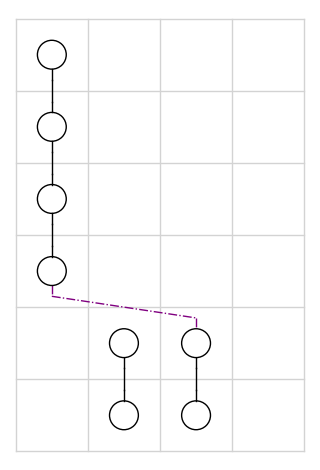

[3, 1]

In [192]:
# Z = [[1,1,0,-1,0],[1,1,0,-1,0]]
# Y = [[0,1,-1,1,-1],[0,-1,1,1,-1]]
# X = [[1,0,1,-1,-1],[1,0,-1,-1,1]]

# Z = [[1,0,0,1,0],[1,0,0,1,0]]
# Y = [[0,1,1,1,-1],[0,1,1,1,-1]]
# X = [[1,0,1,-1,-1],[1,0,-1,-1,1]]

Z = [[1,1,0,1,0,-1,0],[1,1,0,1,0,-1,0]]
Y = [[0,0,1,0,1,-1,-1],[0,0,1,0,-1,-1,1]]
X = [[0,-1,0,-1,-1,1,1],[0,-1,0,-1,-1,1,1]]

balls = X + Y + Z

balls = [[0, 1, 1, 0], [0, 1, 1, 0], [1, 0, 0, 0], [1, 0, 0, 0], [1, 0, 0, 0], [1, 0, 0, 0]]

M = MultilineQueueC(balls)
M.pair(0)
M.draw(0.2)
M.partition()

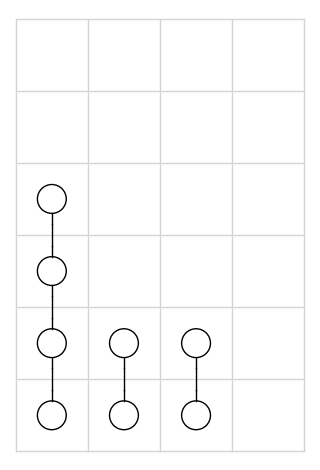

 1  1  2
 3



In [193]:
balls2 = M.collapse_and_record()

if balls2 != "Already collapsed!":
    M2 = MultilineQueueC(balls2)
    M2.pair(0)
    M2.draw(0.2)
    
    print_list_of_lists(M.QM)


In [194]:
M2.partition()

[2, 1, 1]

In [196]:
Q = M.QM
Q

[[1, 1, 2], [3], []]

In [197]:
shape(Q)

[3, 1]

In [198]:
core_shape(Q),M2.partition().conjugate()

([3, 1], [3, 1])

### Experiments

In [27]:
lam = [2,2,1]
n = 5

typeC_mlqs = all_typeC_MLQs(lam,n)

print(len(typeC_mlqs))

19360


In [16]:
# Checking that the recording object has the correct properties in terms of core shape

for j in range(len(typeC_mlqs)):
    M = copy.deepcopy(typeC_mlqs[j])
    balls_col = M.collapse_and_record()
    Q = copy.deepcopy(M.QM)
    
    # 1) Check the shape of the recording tableau
    shapeQ = shape(Q)
    coreQ = core_shape(Q)

    # 2) Find the shape of the collapsed MLQ
    Mcol = MultilineQueueC(balls_col)
    Mcol.pair(0)
    shape_col = Mcol.partition().conjugate()

    if shape_col != coreQ:
        print("Mistake!")
        print(M.balls)
        print(Q)
        print(shape_col,coreQ)

In [39]:
# Generate all collapsed and recording objects for the n and lam above

all_rec_objs = []
all_collapsed_objs = []

for j in range(len(typeC_mlqs)):
    M = copy.deepcopy(typeC_mlqs[j])
    # print(M.balls)
    balls_col = M.collapse_and_record()
    Q = copy.deepcopy(M.QM)

    if Q not in all_rec_objs:
        all_rec_objs.append(Q)

    if balls_col not in all_collapsed_objs:
        all_collapsed_objs.append(balls_col)

all_rec_objs = [remove_trailing_empties(T) for T in all_rec_objs]

print(all_rec_objs)

print(len(all_collapsed_objs))


[[[1, 1], [2, 2], [3]], [[1, 1, 3], [2, 2]], [[1, 1], [2, 2], [-3]], [[1, 1, 2], [2], [3]], [[1, 1, 2], [2, 3]], [[1, 1, 2], [2], [-3]], [[1, 1, 2, 3], [2]], [[1, 1, 2, 2], [3]], [[1, 1, 2, 2, 3]], [[1, 1, 2, 2], [-3]], [[1, 1, 2], [-2, 3]], [[1, 1, 2], [2, -3]], [[1, 1, 2, 3], [-2]], [[1, 1, 3], [2, -2]], [[1, 1], [2, -2], [3]], [[1, 1], [2, -2], [-3]], [[1, 1, 2], [-2, -3]], [[1, 1, 3], [-2, -2]]]
13892


In [40]:
for R in all_rec_objs:
    print(R)

[[1, 1], [2, 2], [3]]
[[1, 1, 3], [2, 2]]
[[1, 1], [2, 2], [-3]]
[[1, 1, 2], [2], [3]]
[[1, 1, 2], [2, 3]]
[[1, 1, 2], [2], [-3]]
[[1, 1, 2, 3], [2]]
[[1, 1, 2, 2], [3]]
[[1, 1, 2, 2, 3]]
[[1, 1, 2, 2], [-3]]
[[1, 1, 2], [-2, 3]]
[[1, 1, 2], [2, -3]]
[[1, 1, 2, 3], [-2]]
[[1, 1, 3], [2, -2]]
[[1, 1], [2, -2], [3]]
[[1, 1], [2, -2], [-3]]
[[1, 1, 2], [-2, -3]]
[[1, 1, 3], [-2, -2]]


In [41]:
# Find all shapes of recording objects found

all_shapes = []

for T in all_rec_objs:
    sh = shape(T)

    if sh not in all_shapes:
        all_shapes.append(sh)

print(all_shapes)

[[2, 2, 1], [3, 2], [3, 1, 1], [4, 1], [5]]


In [42]:
list(reversed(get_all_dominating(lam)))

[[2, 2, 1], [3, 1, 1], [3, 2], [4, 1], [5]]

In [43]:
# Find all core shapes of recording objects found

all_core_shapes = []

for T in all_rec_objs:
    sh = core_shape(T)

    if sh not in all_core_shapes:
        all_core_shapes.append(sh)

print(all_core_shapes)

[[2, 2, 1], [3, 2], [2, 1], [3, 1, 1], [3], [4, 1], [5], [1, 1, 1], [1]]


In [44]:
# Find all recording objects of a given shape

given_shape = [3,1,1]

recs_given_shape = []

for T in all_rec_objs:
    sh = shape(T)

    if sh == given_shape:
        recs_given_shape.append(T)

for R in recs_given_shape:
    print(R)

print(len(recs_given_shape))

[[1, 1, 2], [2], [3]]
[[1, 1, 2], [2], [-3]]
2


In [45]:
# Checking sizes for all valid partitions

for given_shape in list(reversed(get_all_dominating(lam))):

    recs_given_shape = []

    for T in all_rec_objs:
        sh = shape(T)
    
        if sh == given_shape:
            recs_given_shape.append(T)

    my_recs = my_recording_objects(n,given_shape,lam)
            
    if len(recs_given_shape) != len(my_recs):
        print("Mistake")
        print(given_shape)
        print("\n")

In [46]:
# Checking sizes

ans = 0

for core in all_core_shapes:
    num_recs_given_core_shape = 0

    for T in all_rec_objs:
        sh = core_shape(T)
    
        if sh == core:
            num_recs_given_core_shape += 1

    num_coll_given_part = 0

    for i in range(len(all_collapsed_objs)):
        bs = all_collapsed_objs[i]
        M = MultilineQueueC(bs)
        if M.partition().conjugate() == core:
            num_coll_given_part += 1

    ans += num_coll_given_part*num_recs_given_core_shape

    print(core,num_coll_given_part,num_recs_given_core_shape)

print("\n")
print(ans,len(typeC_mlqs))

[2, 2, 1] 4620 1
[3, 2] 2860 2
[2, 1] 320 4
[3, 1, 1] 4212 1
[3] 110 3
[4, 1] 1408 2
[5] 132 1
[1, 1, 1] 220 1
[1] 10 3


19360 19360


In [50]:
#Check sizes of nonleftbouncing MLQs directly

for core in all_core_shapes:
    print(core,len(all_nonleftbouncing_typeC_MLQs(core,n)))

[2, 2, 1] 4620
[3, 2] 2860
[2, 1] 320
[3, 1, 1] 4212
[3] 110
[4, 1] 1408
[5] 132
[1, 1, 1] 220
[1] 10


# R-matrices in type A and C

## Examples (old)

In [31]:
%run Crystals.ipynb
%run MultilineQueuesTypeC.ipynb

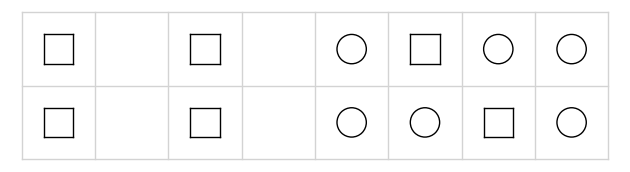

[-2, 0, -2, 0, -1, 1, 2, -1]


[0, 0, 0, 0, 0, 1, 1, 0]

In [63]:
%run MultilineQueuesTypeC.ipynb

## TEST: boundary conditions, empty the_list, moves of the labels

n = 8
Q1 = [7,-7,-1,8,-3,5]
balls = to_number_matrix_arrays(n,[Q1])

M = MultilineQueueC(balls)
r = 0.2
M.draw(r)

w = column_matching_word(balls)
print(w)

parenthesis_matching(w)

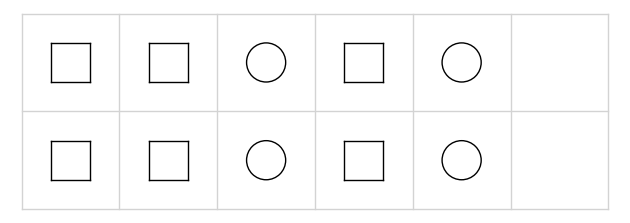

In [35]:
j = 2
balls2 = botRem(balls,j)

M2 = MultilineQueueC(balls2)
M2.draw(r)

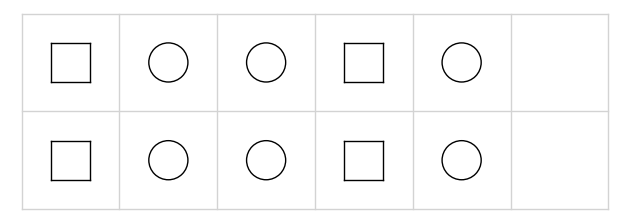

In [36]:
j = 2
balls2 = topRem(balls,j)

M2 = MultilineQueueC(balls2)
M2.draw(r)

In [30]:
print(balls[0])
list(reversed(balls[0]))

[-1, 1, 1, -1, 1, -1]


[-1, 1, -1, 1, 1, -1]

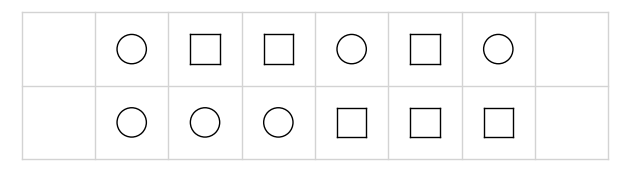

[0, -1, 1, 1, 2, -2, 2, 0]


[0, 0, 2, 1, 1, 0, 2, 0]

In [66]:
# Testing insertions

%run MultilineQueuesTypeC.ipynb


n = 8
Q1 = [5,-5,-6,7,-7,2]
balls = to_number_matrix_arrays(n,[Q1])

M = MultilineQueueC(balls)
r = 0.2
M.draw(r)

w = column_matching_word(balls)
print(w)

parenthesis_matching(w)

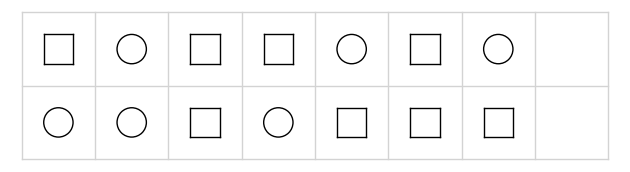

In [71]:
typ = -1
j = 3

balls2 = botIns(balls,typ,j)

if type(balls2) == str:
    print(balls2)

else:
    M2 = MultilineQueueC(balls2)
    M2.draw(r)

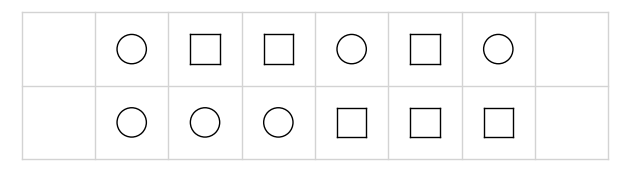

True


In [72]:
balls3 = botRem(balls2,j)

M3 = MultilineQueueC(balls3)
M3.draw(r)

print(balls == balls3)

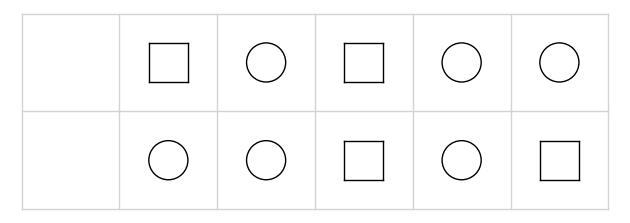

['', 'u', '', 'u', 'u', '']

In [12]:
k = 1
unm_list = ["","u","","u","u",""]
[balls2,col,unm] = rem(balls,k,unm_list)

M2 = MultilineQueueC(balls2)
M2.draw(r)
unm

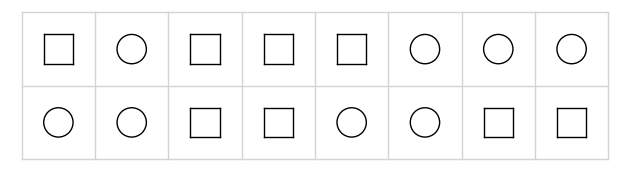

[1, -1, -2, -2, 1, -1, 2, 2]


[2, 0, 0, 0, 1, 0, 1, 2]

In [8]:
%run MultilineQueuesTypeC.ipynb

## TEST: boundary conditions, empty the_list, moves of the labels

n = 8
Q1 = [-3,2,8,-8,7,-7,6,-4]
balls = to_number_matrix_arrays(n,[Q1])

M = MultilineQueueC(balls)
r = 0.2
M.draw(r)

w = column_matching_word(balls)
print(w)

parenthesis_matching(w)

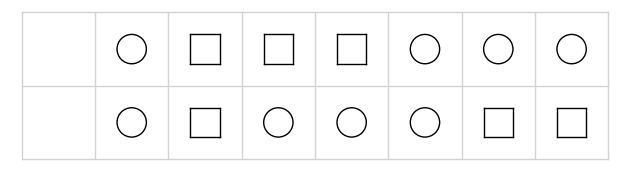

['', '', '', 'u', '', 'u', 'u', 'u']

In [9]:
k = 4
unm_list = ["","u","","u","","u","u","u"]
[balls2,col,unm] = rem(balls,k,unm_list)

M2 = MultilineQueueC(balls2)
M2.draw(r)
unm

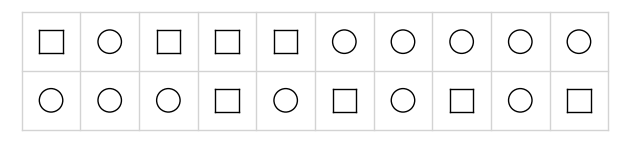

Left to right:


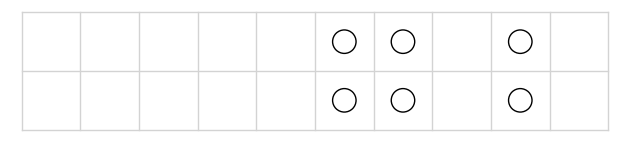

--------------
All orders coincide with left-to-right! :)


In [14]:
# Removal testing

%run MultilineQueuesTypeC.ipynb

r = 0.2
n = 10
Q1 = [9,2,8,-8,6,-6,7,-4,10,-10]
balls = to_number_matrix_arrays(n,[Q1])

M = MultilineQueueC(balls)
M.draw(r)

unm_list= ["u","u","u","u","","u","","u","","u"]

from itertools import product

def all_bounded_lists(k):
    ranges = [range(1, k - i + 1) for i in range(k)]
    return list(product(*ranges))

all_orders = [list(x) for x in all_bounded_lists(unm_list.count("u"))]

balls_comp = ordered_removal(balls,unm_list,[1]*(unm_list.count("u")))
M = MultilineQueueC(balls_comp)
print("Left to right:")
M.draw(r)
print("--------------")

ans = True
for order in all_orders:
    balls2 = ordered_removal(balls,unm_list,order)

    if balls2 != balls_comp:
        print(f"MISTAKE with {order}")    
        ans = False
        M2 = MultilineQueueC(balls2)
        M2.draw(r)

if ans:
    print("All orders coincide with left-to-right! :)")



### Type A

In [68]:
n = 7
row1 = [1,2,4,5]
r1 = len(row1)
row2 = [2,3,6]
r2 = len(row2)

print(R_matrix_A_two_rows(n,r1,r2,row1,row2))

[[[1], [2], [5]], [[2], [3], [4], [6]]]


### Type C

In [6]:
n = 5
row1 = [4,-4,-3,-2]
r1 = len(row1)
row2 = [-3,-1]
r2 = len(row2)

print(R_matrix_C_two_rows(n,r1,r2,row1,row2))


[[[-3], [-2]], [[4], [-4], [-3], [-1]]]


In [13]:
n = 5
row1 = [3,-1]
r1 = len(row1)
row2 = [2]
r2 = len(row2)

print(R_matrix_C_two_rows(n,r1,r2,row1,row2))

[[[-1]], [[2], [3]]]


In [14]:
f_row1 = fi_type_C(n,r2,row2,2)
print(f_row1)

[[3]]


In [140]:
i = 3
row = row1
x = ei_type_C(n,len(row),row,i)
ans = list(x.to_kirillov_reshetikhin_tableau())
ans2 = [int(str(x)) for x in ans]

print(ans2)

[-5, 5, 3]


In [141]:
n = 5
row1 = [3,5,-5]
r1 = len(row1)
row2 = [5,-5,-4,-3]
r2 = len(row2)

print(R_matrix_C_two_rows(n,r1,r2,row1,row2))

[[[2], [3], [5], [-5]], [[-4], [-3], [-2]]]


In [142]:
row = [2,4,5,-5]
x = ei_type_C(n,len(row),row,i)
ans = list(x.to_kirillov_reshetikhin_tableau())
ans2 = [int(str(x)) for x in ans]

print(ans2)

[-5, 5, 3, 2]


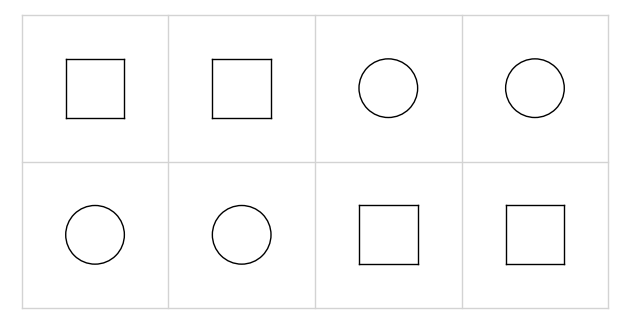

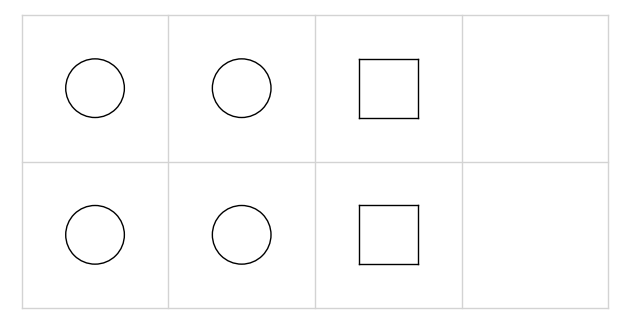

In [111]:
balls = to_number_matrix_arrays(n,[row2])

M = MultilineQueueC(balls)
r = 0.2
M.draw(r)

balls = to_number_matrix_arrays(n,[row1])

M = MultilineQueueC(balls)
r = 0.2
M.draw(r)

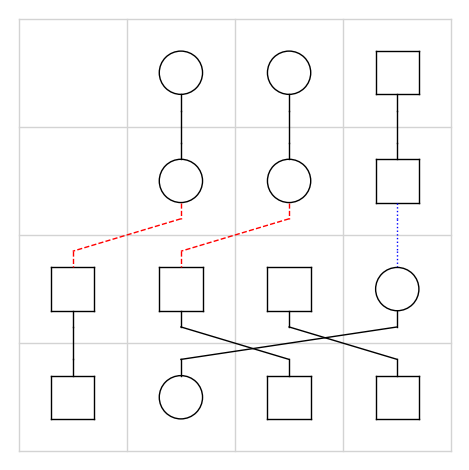

In [34]:
%run MultilineQueuesTypeC.ipynb

balls = [[-1,1,-1,-1], [-1,-1,-1,1], [0,1,1,-1], [0,1,1,-1]]

M = MultilineQueueC(balls)
M.pair(0)
r = 0.2
M.draw(r)

In [5]:
n = 6
row1 = [1,3,-6,-5,-2]
r1 = len(row1)
row2 = [5,6,-6,-5,-4,-2]
r2 = len(row2)
print(R_matrix_C_two_rows(n,r1,r2,row1,row2))


KeyboardInterrupt: 

In [17]:
n = 5
row1 = [4,5,-5,-4,-3]
r1 = len(row1)
row2 = [5,-3,-2,-1]
r2 = len(row2)

print(R_matrix_C_two_rows(n,r1,r2,row1,row2))


[[[5], [-5], [-4], [-3]], [[4], [5], [-3], [-2], [-1]]]


In [50]:
n = 5
row1 = [3,4,5,-4,-2]
row2 = [1,3,5,-4]

print(R_matrix_C_two_rows(n,len(row1),len(row2),row1,row2))

[[[2], [3], [5], [-2]], [[1], [3], [5], [-4], [-2]]]


In [39]:
n = 5
row1 = [3,-3]
row2 = [3,4,-3]

print(R_matrix_C_two_rows(n,len(row1),len(row2),row1,row2))

[[[4], [-4], [-3]], [[3], [4]]]


In [30]:
## Produces the projections of all the elements of the tensor product
%run Crystals.ipynb
n = 3
lam = [3,3,1]

list_crystals = []

#Compute the tensor product of crystals
for i in range(len(lam)):
    list_crystals.append(crystals.KirillovReshetikhin(['C',n,1],lam[i],1))

prod = crystals.TensorProduct(*list_crystals)

states = []

print("Number of MLQs: "+str(len(prod)))
cant = 0
for p in prod:
    r = 0.2
    balls = to_number_matrix(n,p)
    M = MultilineQueueC(balls)
    M.pair(0)
    proj_MLQ = M.projection()
    if proj_MLQ != projection_map(n,p):
        print("wrong")
        print(proj_MLQ , projection_map(n,p))


Number of MLQs: 1176


## Comb R in Type C using the Rem/Ins procedure

In [330]:
%run MultilineQueuesTypeC.ipynb

In [361]:
n = 6
row1 = [1,5,-6]
row2 = [2,3,-6,-3]

m = len(row2)-len(row1)

Rmat_res = R_matrix_C_two_rows(n,len(row1),len(row2),row1,row2)
print(Rmat_res)

[[[1], [2], [5], [-6]], [[2], [-6], [-2]]]


In [362]:
Rrow1 = [x[0] for x in Rmat_res[0].to_tableau()]
Rrow2 = [x[0] for x in Rmat_res[1].to_tableau()]

print(Rrow1,Rrow2)

[1, 2, 5, -6] [2, -6, -2]


In [363]:
balls1 = to_number_matrix_arrays(n,[row1])
balls2 = to_number_matrix_arrays(n,[row2])

print([balls1,balls2])

Rballs1 = to_number_matrix_arrays(n,[Rrow1])
Rballs2 = to_number_matrix_arrays(n,[Rrow2])

[[[1, 0, 0, 0, 1, -1], [1, 0, 0, 0, 1, -1]], [[1, 1, -1, 0, 0, -1], [-1, 1, 1, 0, 0, -1]]]


In [364]:
print([Rballs1,Rballs2])

[[[1, 1, 0, 0, 1, -1], [1, 1, 0, 0, 1, -1]], [[1, -1, 0, 0, 0, -1], [-1, 1, 0, 0, 0, -1]]]


In [365]:
rowOpResult = row_operator_power(balls1,balls2,m)
print(rowOpResult)

[[[1, 1, 0, 0, 1, -1], [1, 1, 0, 0, 1, -1]], [[1, -1, 0, 0, 0, -1], [-1, 1, 0, 0, 0, -1]]]


In [ ]:
[Rballs1,Rballs2]==rowOpResult

# Some type C Markov chains

## Open boundary TASEP 

In [171]:
#Check the states that occur in the previous process

seen = set()
unique_states = []

for sublist in states:
    t = tuple(sublist)
    if t not in seen:
        seen.add(t)
        unique_states.append(sublist)

#print(unique_states)

print(f"\nTotal states seen: {len(unique_states)}")


Total states seen: 24


In [25]:
print(unique_states)

[[2, 1], [1, 2], [2, -1], [1, -2], [-2, 1], [-1, 2], [-2, -1], [-1, -2]]


In [172]:
# Generating all states (Thanks ChatGPT):

from itertools import permutations, product

def signed_permutations(nums):
    # Generate all unique permutations (handles repeated elements)
    unique_perms = set(permutations(nums))

    result = []
    for perm in unique_perms:
        # Generate sign variants: flip sign for positive integers only
        sign_variants = [
            [n, -n] if n > 0 else [0]  # 0 stays as 0
            for n in perm
        ]
        # Create all combinations of sign variants
        signed_versions = product(*sign_variants)
        
        # Convert each tuple to list before adding
        result.extend([list(signed) for signed in signed_versions])

    return result

# Example usage

lam_prime = list(Partition(lam).conjugate())

nums = lam_prime + [0 for m in range(n-len(lam_prime))]
all_states = signed_permutations(nums)

#print(all_states)

print(f"\nTotal states: {len(all_states)}")


Total states: 24


In [76]:
# Creates a .txt file with the data of the distribution for the states

# Open the file in write mode ('w'). 
# If the file doesn't exist, it will be created. 
# If it exists, its content will be truncated (emptied).

file_name = '('+str(nums)+', n='+str(n)+').txt'

with open(file_name, 'w') as f:
    for s in all_states:
        f.write(str(s) + " : " + str(states.count(s))+'\n')
    # You can also write variables (convert them to strings first)
    #number = 123
    #f.write(f'The number is: {number}\n')

In [173]:
# See the distribution as an output in here...

distrib = []
for s in all_states:
    distrib.append(states.count(s))
    print(str(s) + " : " + str(states.count(s)))

[0, 2, 1] : 1
[0, 2, -1] : 4
[0, -2, 1] : 4
[0, -2, -1] : 5
[1, 2, 0] : 5
[1, -2, 0] : 4
[-1, 2, 0] : 4
[-1, -2, 0] : 1
[2, 1, 0] : 1
[2, -1, 0] : 8
[-2, 1, 0] : 2
[-2, -1, 0] : 5
[2, 0, 1] : 2
[2, 0, -1] : 3
[-2, 0, 1] : 3
[-2, 0, -1] : 4
[0, 1, 2] : 5
[0, 1, -2] : 8
[0, -1, 2] : 2
[0, -1, -2] : 1
[1, 0, 2] : 4
[1, 0, -2] : 3
[-1, 0, 2] : 3
[-1, 0, -2] : 2


In [28]:
# Computing the partition function

sum(distrib)

20

In [29]:
# Confirming the balancing condition with the empiric distribution

#Returns True if s1 -> s2 is a good transition in the ASEP and False otherwise. 
def is_valid_transition(s1,s2):
    n = len(s1)
    diff = [i for i in range(len(s1)) if s1[i] != s2[i]]

    # If too many differences, bad
    if len(diff) > 2 or len(diff) == 0:
        return(False)
    # If only one difference... 
    elif len(diff) == 1:
        ind = diff[0]
        # If not in the edges, bad
        if ind != 0 and ind != n-1:
            return(False)
        elif ind == 0 or ind == n-1:
            # If not bouncing, bad
            if (s1[ind] != (-1)*s2[ind]):
                return(False) 
            # Only neg can bounce on left, only pos can bounce on right
            elif ind == 0 and s1[ind] > 0:
                return(False)
            elif ind == n-1 and s1[ind] < 0:
                return(False)

    # If there are two differences...
    elif len(diff) == 2:
        # If not adjancent, bad
        if (diff[0] + 1 != diff[1]):
            return(False)
        # If particles don't match, bad
        if s1[diff[0]] != s2[diff[1]] or s1[diff[1]] != s2[diff[0]]:
            return(False)        
        # If particle on the left is smaller than the one on the right, bad...
        elif (s1[diff[0]] < s1[diff[1]]):
            return(False)
        
    return(True)


def check_balancing(s):
    incoming = [t for t in unique_states if is_valid_transition(t,s)]
    outgoing = [r for r in unique_states if is_valid_transition(s,r)]
    
    lhs = (states.count(s))*len(outgoing)
    rhs = sum([states.count(t) for t in incoming])

    #print(lhs,rhs)

    return(lhs == rhs)

In [30]:
for s in unique_states:
    if not check_balancing(s):
        print(s)

## Markov Chain on MLQs (one-row case)

In [46]:
# Produces the projections of all the elements of the tensor product

n = 6
k = 4
lam = [k]

show_all = False

show_proj = True
state_proj = [0,1,1,-1,1,0]

#########################################################

C1 = crystals.KirillovReshetikhin(['C',n,1],lam[0],1)

prod = crystals.TensorProduct(C1)

states = []
states_rows = []

print("Number of MLQs: "+str(len(prod)))

for p in prod:
    balls = to_number_matrix(n,p)
    M = MultilineQueueC(balls)
    M.pair(0)
    states.append(M.projection())
    states_rows.append(balls)
    
    if show_all:
        print(p)
        print(balls)
        print("Queues")
        for q in M.queues:
            print(q)
        print("\n")
    
    if show_proj:
        if M.projection() == state_proj:
            print(p)
            print(balls)
            print("Queues")
            for q in M.queues:
                print(q)
            print("\n")
    

Number of MLQs: 429
[[[2], [3], [5], [-4]]]
[[0, 1, 1, -1, 1, 0], [0, 1, 1, -1, 1, 0]]
Queues
[[2, 2, 'p'], [1, 2, 'p']]
[[2, 3, 'p'], [1, 3, 'p']]
[[2, 4, 'n'], [1, 4, 'n']]
[[2, 5, 'p'], [1, 5, 'p']]


[[[2], [4], [5], [-4]]]
[[0, 1, 1, -1, 1, 0], [0, 1, -1, 1, 1, 0]]
Queues
[[2, 2, 'p'], [1, 2, 'p']]
[[2, 3, 'n'], [1, 4, 'n']]
[[2, 4, 'p'], [1, 3, 'p']]
[[2, 5, 'p'], [1, 5, 'p']]


[[[3], [4], [5], [-4]]]
[[0, 1, 1, -1, 1, 0], [0, -1, 1, 1, 1, 0]]
Queues
[[2, 2, 'n'], [1, 4, 'n']]
[[2, 3, 'p'], [1, 3, 'p']]
[[2, 4, 'p'], [1, 2, 'p']]
[[2, 5, 'p'], [1, 5, 'p']]




In [41]:
def give_cols(state):
    return([[state[0][j],state[1][j]] for j in range(n)])

states_MC_rows = [give_cols(s) for s in states_rows]

In [42]:
# True if the transition is valid, False if it isn't!
def is_valid_transition_rows(s1,s2):
    n = len(s1)
    diff = [i for i in range(len(s1)) if s1[i] != s2[i]]
    # If too many differences, bad
    if len(diff) > 2 or len(diff) == 0:
        return(False)
    # If only one difference... 
    elif len(diff) == 1:
        ind = diff[0]
        # If not in the edges, bad
        if ind != 0 and ind != n-1:
            return(False)
        elif ind == 0 or ind == n-1:
            # If bouncing on the right
            if (s1[n-1] == [1,1] and s2[n-1] == [-1,-1]):
                return(True) 
            # If bouncing on the left
            elif (s1[0] == [-1,-1] and s2[0] == [1,1]):
                return(True)
            else:
                return(False)

    # If there are two differences...
    elif len(diff) == 2:
        # If not adjancent, bad
        if (diff[0] + 1 != diff[1]):
            return(False)

        # SIMPLE MOVES
        # If circles move right
        if (s1[diff[0]] == [1,1] and (s1[diff[1]] == [0,0] or s1[diff[1]] == [-1,-1])) and (s2[diff[1]] == s1[diff[0]] and (s2[diff[0]] == s1[diff[1]])):
            return(True)   
        # If squares move left
        if (s1[diff[1]] == [-1,-1] and s1[diff[0]] == [0,0]) and (s2[diff[1]] == s1[diff[0]] and s2[diff[0]] == s1[diff[1]]):
            return(True) 
        
        # TWISTING
        elif (s1[diff[0]] == [1,1] and s1[diff[1]] == [-1,-1]) and (s2[diff[0]] == [1,-1] and s2[diff[1]] == [-1,1]):
            return(True)
            
        #UNTWISTING
        elif (s1[diff[0]] == [1,-1] and s1[diff[1]] == [-1,1]) and (s2[diff[0]] == [-1,-1] and s2[diff[1]] == [1,1]):
            return(True)

        #TOP SLIDE
        elif (s1[diff[0]] == [1,1] and s1[diff[1]] == [1,-1]) and (s2[diff[0]] == [1,-1] and s2[diff[1]] == [1,1]):
            return(True)
        elif (s1[diff[0]] == [-1,1] and s1[diff[1]] == [-1,-1]) and (s2[diff[0]] == [-1,-1] and s2[diff[1]] == [-1,1]):
            return(True)

        #BOTTOM SLIDE
        elif (s1[diff[0]] == [1,-1] and s1[diff[1]] == [-1,-1]) and (s2[diff[0]] == [-1,-1] and s2[diff[1]] == [1,-1]):
            return(True)
        elif (s1[diff[0]] == [1,1] and s1[diff[1]] == [-1,1]) and (s2[diff[0]] == [-1,1] and s2[diff[1]] == [1,1]):
            return(True)

        # Otherwise...
        else:
            return(False)

In [43]:
#Confirming balancing condition for this MC

for state1 in states_rows:
    s1 = give_cols(state1)
    in_states = []
    out_states = []

    for state2 in states_rows:
        s2 = give_cols(state2)
        if is_valid_transition_rows(s1,s2):
            out_states.append(s2)
        elif is_valid_transition_rows(s2,s1):
            in_states.append(s2)

    #print(len(in_states),len(out_states))

    if len(in_states) != len(out_states):
        print(s1)
        print(in_states)
        print(out_states)
        print("\n")

## Lumping between C-ASEP and the MC on rows

In [44]:
for s1 in states:
    for s2 in states:
        if is_valid_transition(s1,s2):
            preim_s1 = []
            preim_s2 = []
            for p in prod:
                balls = to_number_matrix(n,p)
                M = MultilineQueueC(balls)
                M.pair(0)
                if M.projection() == s1:
                    preim_s1.append(balls)
                elif M.projection() == s2:
                    preim_s2.append(balls)
            
            for r1 in preim_s1:
                cont = 0
                for r2 in preim_s2:
                    if is_valid_transition_rows(give_cols(r1),give_cols(r2)):
                        cont += 1
                if (cont != 1):
                    print(cont)
                    print(s1,s2)
                    print(preim_s1)
                    print(preim_s2)

In [36]:
K1 = crystals.KirillovReshetikhin(['C',4,1], 2,1)
K2 = crystals.KirillovReshetikhin(['C',4,1], 4,1)




In [52]:
b1 = K1[3]

b1

[[1], [4]]

In [55]:
b2 = K2[23]

f = K1.R_matrix(K2)

In [60]:
K = crystals.KirillovReshetikhin(['C',4,1],2,1)
L = crystals.KirillovReshetikhin(['C',4,1],4,1)
f = K.R_matrix(L)
[[b,f(b)] for b in crystals.TensorProduct(K,L)]

[[[[[1], [2]], [[1], [2], [3], [4]]], [[[1], [2], [3], [4]], [[1], [2]]]],
 [[[[1], [2]], [[1], [2], [3], [-4]]], [[[1], [2], [3], [-4]], [[1], [2]]]],
 [[[[1], [2]], [[1], [2], [4], [-4]]], [[[1], [2], [4], [-4]], [[1], [2]]]],
 [[[[1], [2]], [[1], [3], [4], [-4]]], [[[1], [2], [4], [-4]], [[1], [3]]]],
 [[[[1], [2]], [[2], [3], [4], [-4]]], [[[1], [2], [4], [-4]], [[2], [3]]]],
 [[[[1], [2]], [[1], [2], [4], [-3]]], [[[1], [2], [4], [-3]], [[1], [2]]]],
 [[[[1], [2]], [[1], [3], [4], [-3]]], [[[1], [2], [4], [-3]], [[1], [3]]]],
 [[[[1], [2]], [[2], [3], [4], [-3]]], [[[1], [2], [4], [-3]], [[2], [3]]]],
 [[[[1], [2]], [[1], [3], [4], [-2]]], [[[1], [3], [4], [-3]], [[1], [3]]]],
 [[[[1], [2]], [[2], [3], [4], [-2]]], [[[1], [3], [4], [-3]], [[2], [3]]]],
 [[[[1], [2]], [[2], [3], [4], [-1]]], [[[2], [3], [4], [-3]], [[2], [3]]]],
 [[[[1], [2]], [[1], [2], [-4], [-3]]], [[[1], [2], [-4], [-3]], [[1], [2]]]],
 [[[[1], [2]], [[1], [3], [-4], [-3]]], [[[1], [2], [-4], [-3]], [[1], [3]]]

# Algebraic Combinatorics (in progress...)

In [1]:
%run MultilineQueuesTypeC.ipynb
%run Crystals.ipynb

In [2]:
n = 3
lam = [2,1]

list_crystals = []
for i in range(len(lam)):
    list_crystals.append(crystals.KirillovReshetikhin(['C',n,1],lam[i],1))
prod = crystals.TensorProduct(*list_crystals)

len(prod)

84

In [5]:
def all_positive_coefficients(f):
    ans = True
    for coeff in f.coefficients():
        if coeff < 0:
            ans = False
            break
    return(ans)

In [6]:
# Create dictionary with the Schur's

# CAREFUL #

k = 7
n = 7

with open("Schurs_parts"+str(k)+"_vars"+str(n)+".txt", "w") as f:
    for part in Partitions(k):
        result = s_hat(n,part)
        f.write(f"{part}: {result}\n")
        print(part)

[7]
[6, 1]
[5, 2]
[5, 1, 1]
[4, 3]
[4, 2, 1]
[4, 1, 1, 1]
[3, 3, 1]
[3, 2, 2]



KeyboardInterrupt



In [8]:
list(Partitions(7)) #From [3,2,2] onwards

[[7],
 [6, 1],
 [5, 2],
 [5, 1, 1],
 [4, 3],
 [4, 2, 1],
 [4, 1, 1, 1],
 [3, 3, 1],
 [3, 2, 2],
 [3, 2, 1, 1],
 [3, 1, 1, 1, 1],
 [2, 2, 2, 1],
 [2, 2, 1, 1, 1],
 [2, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1]]

In [ ]:
missing = [[3, 2, 1, 1],
 [3, 1, 1, 1, 1],
 [2, 2, 2, 1],
 [2, 2, 1, 1, 1],
 [2, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1]]

k = 7
n = 7

with open("Schurs_parts"+str(k)+"_vars"+str(n)+".txt", "a") as f:
    for part in missing:
        result = s_hat(n,part)
        f.write(f"{part}: {result}\n")
        print(part)



In [7]:
from sage.all import sage_eval

def lookup_value(target_key, filename):
    # Convert the target key to a string for matching
    target_str = str(target_key)
    
    with open(filename, "r") as f:
        for line in f:
            if line.strip():
                # Split at the first colon
                key_str, val_str = line.split(":", 1)
                
                # Check if this is the key we want (stripping whitespace)
                if key_str.strip() == target_str:
                    # Only evaluate the value of the match, saving memory
                    return(sage_eval(val_str.strip(),evaluation_context))
                    
    return(None)  # If key isn't found

In [8]:
n = 4
key = [1,1]
k = sum(key)
filename = "Schurs_parts"+str(k)+"_vars"+str(n)+".txt"

lookup_value(key, filename)

x0^2 + x0*x1 + x1^2 + x0*x2 + x1*x2 + x2^2 + x0*x3 + x1*x3 + x2*x3 + x3^2 + x0*x3^-1 + x1*x3^-1 + x2*x3^-1 + x0*x2^-1 + x1*x2^-1 + x0*x1^-1 + 4 + x0^-1*x1 + x1^-1*x2 + x0^-1*x2 + x2^-1*x3 + x1^-1*x3 + x0^-1*x3 + x3^-2 + x2^-1*x3^-1 + x1^-1*x3^-1 + x0^-1*x3^-1 + x2^-2 + x1^-1*x2^-1 + x0^-1*x2^-1 + x1^-2 + x0^-1*x1^-1 + x0^-2

In [9]:
# Method that gives the terms appearing in P_hat

n = 5
lam = [2,1,1,1]

# Set up the Laurent Polynomial ring

R = LaurentPolynomialRing(coeffs_field,n,'x')
xs = R.gens()

evaluation_context = {}
for i in range(n):
    evaluation_context['x'+str(i)] = xs[i]

# Compute the polynomial and its components

f = P_hat(n,lam)
terms = []

while f != 0:

    mu = list(f.monomials()[0].exponents()[0])
    part = Partition(mu).conjugate()
    terms.append(part)
    k = sum(part)
    filename = "Schurs_parts"+str(k)+"_vars"+str(n)+".txt"

    g = lookup_value(part, filename)
    f = R(f)-R(g)
    
print("Done")

Done


In [10]:
set_terms = set(terms)

for s in set_terms:
    print(s,":",terms.count(s))

[2, 1] : 9
[5] : 1
[1] : 6
[3] : 6
[2, 2, 1] : 2
[3, 2] : 3
[1, 1, 1] : 3
[4, 1] : 3
[3, 1, 1] : 3
[2, 1, 1, 1] : 1
